In [1]:
import pandas as pd

from index_calculation import index_levels
from index_utils import rebase, turnover
from instrument_data import combine, to_wide
from plot import plot_index_levels, plot_turnover
from providers.csv_provider import load_market_cap, load_prices
from rebalance_date import month_end
from selection import top_n
from weighting import equal_weights

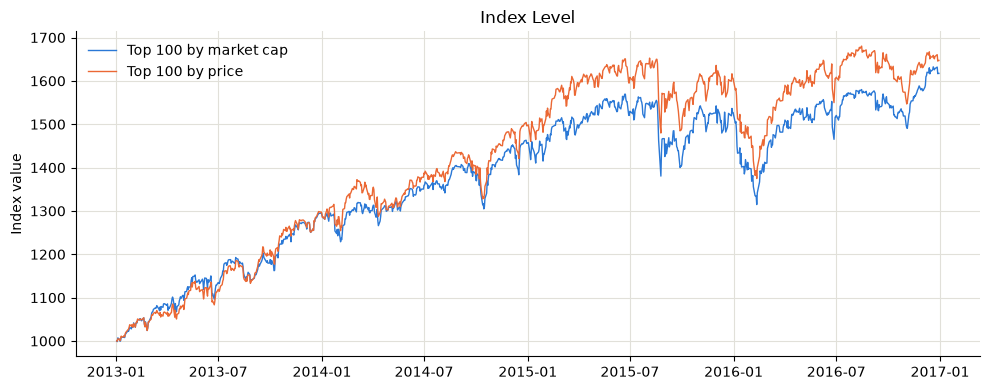

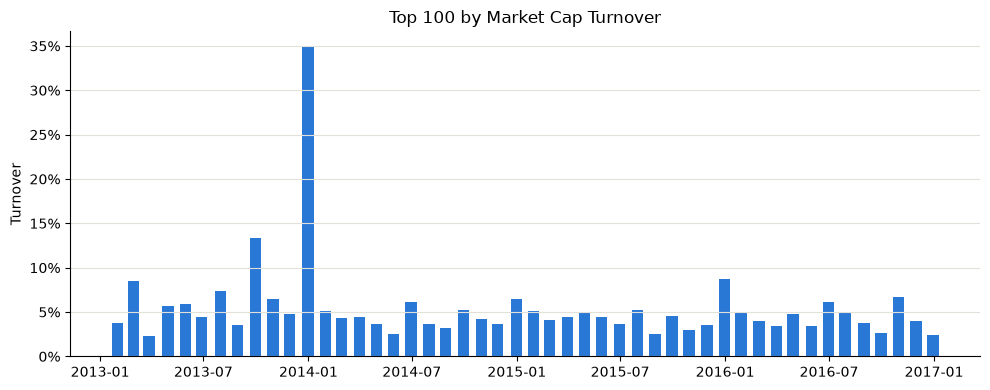

In [2]:
prices = load_prices()
market_cap = load_market_cap(prices)
price_and_market_cap = combine(prices, market_cap)

close_raw = to_wide(prices, "price")

base_date = pd.Timestamp("2010-01-04")
rebalance_dates = month_end(close_raw.index, base_date)

# Fundamentals coverage (shares outstanding) only clears 100 filed symbols by early 2013,
# so the market-cap variant needs its own, later base date
market_cap_base_date = pd.Timestamp("2013-01-02")
market_cap_rebalance_dates = month_end(close_raw.index, market_cap_base_date)

top100_market_cap_equal_weighted = index_levels(
    instrument_data=price_and_market_cap,
    base_date=market_cap_base_date,
    rebalance_dates=market_cap_rebalance_dates,
    selection_algo=lambda instrument_values: top_n(instrument_values, 100, "market_cap"),
    weighting_algo=equal_weights,
)

top100_price_equal_weighted = index_levels(
    instrument_data=prices,
    base_date=base_date,
    rebalance_dates=rebalance_dates,
    selection_algo=lambda instrument_values: top_n(instrument_values, 100, "price"),
    weighting_algo=equal_weights,
)

# Rebase both to the market-cap variant's start date so they're directly comparable
comparable_market_cap = rebase(top100_market_cap_equal_weighted.levels, market_cap_base_date)
comparable_price = rebase(top100_price_equal_weighted.levels, market_cap_base_date)

market_cap_turnover = turnover(top100_market_cap_equal_weighted.weights, market_cap_rebalance_dates)

fig, ax = plot_index_levels({
    "Top 100 by market cap": comparable_market_cap,
    "Top 100 by price": comparable_price,
})

fig2, ax2 = plot_turnover(market_cap_turnover, title="Top 100 by Market Cap Turnover")